# Week 4: Replicating the RSM and SVM Models

**Goal:** Replicate the results for the Response Surface Methodology (RSM) and Support Vector Machine (SVM) models as described in the Masoumi et al. (2024) reference paper.

**Methodology:**
1.  **Load Data:** Import the clean, processed dataset from the previous EDA step.
2.  **Preprocess Data:** The reference paper specifies two key steps:
    * [cite_start]Normalization of all features to a `[-1, 1]` range[cite: 3193].
    * [cite_start]Splitting the data into a `70:15:15` ratio for training, validation, and testing[cite: 3201].
3.  **Implement RSM:** Build a quadratic regression model using `statsmodels` to replicate the paper's Design-Expert results. [cite_start]Our target is an R² of **0.9802**[cite: 2937].
4.  **Implement SVM:** Build a Support Vector Regressor (SVR) using `scikit-learn`, configured with the exact parameters from the paper. [cite_start]Our target is a training R² of **0.8946** and an MSE of **0.1623**[cite: 2937, 4116].
5.  **Evaluate:** Compare our model's performance metrics (R² and MSE) against the values reported in the paper.

In [13]:
# --- Step 1: Setup and Data Loading ---

# Import necessary libraries
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Define project path and load the CLEANED dataset
PROJECT_PATH = '/content/drive/MyDrive/CO2-Capture-ML/'
cleaned_file_path = '/content/drive/MyDrive/CO2-Capture-ML/Data/Processed/Cleaned_Data.csv'
df = pd.read_csv(cleaned_file_path)

print("--- Cleaned data loaded successfully ---")
df.info()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- Cleaned data loaded successfully ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 293 entries, 0 to 292
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   temperature_k                 293 non-null    float64
 1   CO2​ Loading (mol/mol_alk)    293 non-null    float64
 2   PCO2∗​ (Pa)                   293 non-null    float64
 3   Target -> kg′​ (mol/s·Pa·m²)  290 non-null    float64
 4   conc_aep_m                    293 non-null    int64  
 5   conc_amp_m                    293 non-null    float64
 6   conc_dga_m                    293 non-null    int64  
 7   conc_dmpz_m                   293 non-null    float64
 8   conc_eda_m                    293 non-null    int64  
 9   conc_hep_m                    293 non-null    float64
 10  conc_mapa_m 

## Step 2: Data Preprocessing for Replication

Before we can build any models, we must prepare the data exactly as described in the reference paper. This ensures our results are comparable. We will use the log-transformed target variable (`log10_target_kg_prime`) that we identified during EDA, as this is standard practice for highly skewed targets.

In [14]:
# Use .T to transpose the output for better readability
df.describe().T

,count,mean,std,min,25%,50%,75%,max
temperature_k,293.0,337.450341,20.919085,3.131500e+02,3.131500e+02,333.150000,353.150000,373.150000
CO2​ Loading (mol/mol_alk),293.0,0.291843,0.119453,2.700000e-02,2.100000e-01,0.285000,0.365000,0.695000
PCO2∗​ (Pa),293.0,11302.492833,30596.068466,4.000000e+00,6.340000e+02,3800.000000,12260.000000,416210.000000
Target -> kg′​ (mol/s·Pa·m²),290.0,0.000003,0.000006,8.000000e-08,6.447500e-07,0.000001,0.000003,0.000082
conc_aep_m,293.0,0.245734,1.191159,0.000000e+00,0.000000e+00,0.000000,0.000000,6.000000
conc_amp_m,293.0,0.212969,0.990072,0.000000e+00,0.000000e+00,0.000000,0.000000,4.800000
conc_dga_m,293.0,0.511945,2.207714,0.000000e+00,0.000000e+00,0.000000,0.000000,10.000000
conc_dmpz_m,293.0,0.066553,0.317591,0.000000e+00,0.000000e+00,0.000000,0.000000,2.000000
conc_eda_m,293.0,0.655290,2.731215,0.000000e+00,0.000000e+00,0.000000,0.000000,12.000000
conc_hep_m,293.0,0.341638,1.588240,0.000000e+00,0.000000e+00,0.000000,0.000000,7.700000


In [15]:
import pandas as pd
import numpy as np

# Let's assume your DataFrame with the messy column names is named 'df'

# 1. Create an explicit dictionary to map old names to new, clean names
column_rename_map = {
    'CO2​ Loading (mol/mol_alk)': 'co2_loading_mol_mol_alk',
    'PCO2∗​ (Pa)': 'p_star_co2_pa',
    "Target -> kg′​ (mol/s·Pa·m²)": 'target_kg_prime'
}

# 2. Rename the columns using the map
df.rename(columns=column_rename_map, inplace=True)

# 3. Convert the newly named target column to a numeric type (float)
# This is a crucial step for modeling
df['target_kg_prime'] = pd.to_numeric(df['target_kg_prime'], errors='coerce')

# 4. Drop any rows that might have failed the conversion
df.dropna(subset=['target_kg_prime'], inplace=True)

# --- Verification ---
# Let's check the info again. All columns should now be numeric with clean names.
print("--- DataFrame Info After Correction ---")
df.info()

print("\n--- Corrected DataFrame Preview ---")
display(df.head())

--- DataFrame Info After Correction ---
<class 'pandas.core.frame.DataFrame'>
Index: 290 entries, 0 to 292
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   temperature_k            290 non-null    float64
 1   co2_loading_mol_mol_alk  290 non-null    float64
 2   p_star_co2_pa            290 non-null    float64
 3   target_kg_prime          290 non-null    float64
 4   conc_aep_m               290 non-null    int64  
 5   conc_amp_m               290 non-null    float64
 6   conc_dga_m               290 non-null    int64  
 7   conc_dmpz_m              290 non-null    float64
 8   conc_eda_m               290 non-null    int64  
 9   conc_hep_m               290 non-null    float64
 10  conc_mapa_m              290 non-null    int64  
 11  conc_mdea_m              290 non-null    int64  
 12  conc_mea_m               290 non-null    int64  
 13  conc_mpz_m               290 non-null    floa

,temperature_k,co2_loading_mol_mol_alk,p_star_co2_pa,target_kg_prime,conc_aep_m,conc_amp_m,conc_dga_m,conc_dmpz_m,conc_eda_m,conc_hep_m,conc_mapa_m,conc_mdea_m,conc_mea_m,conc_mpz_m,conc_pe_m,conc_pz_m
0,313.15,0.252,15.7,3.340000e-06,0,0.0,0,0.0,0,0.0,0,0,7,0.0,0,0.0
1,313.15,0.351,77.0,1.400000e-06,0,0.0,0,0.0,0,0.0,0,0,7,0.0,0,0.0
2,313.15,0.432,465.0,7.660000e-07,0,0.0,0,0.0,0,0.0,0,0,7,0.0,0,0.0
3,313.15,0.496,4216.0,3.470000e-07,0,0.0,0,0.0,0,0.0,0,0,7,0.0,0,0.0
4,333.15,0.252,109.0,2.920000e-06,0,0.0,0,0.0,0,0.0,0,0,7,0.0,0,0.0


In [16]:
# IMPORTANT: Create the log-transformed target variable. This is what we will predict.
# We do this at the start of the modeling notebook to be self-contained.
df['log10_target_kg_prime'] = np.log10(df['target_kg_prime'])

# Define the columns to drop. We want to remove the non-log targets and any
# other temporary columns that might exist. errors='ignore' prevents KeyErrors.
cols_to_drop = ['target_kg_prime', 'log_target_kg_prime']
X = df.drop(columns=cols_to_drop, errors='ignore')

# Now that we've dropped the other targets, the remaining log10 target is our y
y = X.pop('log10_target_kg_prime') # .pop() removes the column from X and assigns it to y

# --- Step 3: Normalization and Splitting ---

# Normalize features to the [-1, 1] range as specified in the paper
scaler = MinMaxScaler(feature_range=(-1, 1))
X_scaled = scaler.fit_transform(X)

# Split the data into 70% training, 15% validation, and 15% testing sets
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print("--- Data is successfully prepared for modeling! ---")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape:   {X_val.shape}, y_val shape:   {y_val.shape}")
print(f"X_test shape:  {X_test.shape}, y_test shape:  {y_test.shape}")

--- Data is successfully prepared for modeling! ---
X_train shape: (203, 15), y_train shape: (203,)
X_val shape:   (43, 15), y_val shape:   (43,)
X_test shape:  (44, 15), y_test shape:  (44,)


## Step 3: Replicating the Response Surface Methodology (RSM) Model

[cite_start]The paper used a quadratic model for its RSM analysis[cite: 3254]. We will replicate this by first generating polynomial features (linear terms, interaction terms like $X_i \times X_j$, and quadratic terms like $X_i^2$) and then fitting a standard Ordinary Least Squares (OLS) regression model to these features.

In [17]:
# 1. Create polynomial features of degree 2 (linear + interaction + quadratic)
poly = PolynomialFeatures(degree=2, include_bias=True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# 2. Fit the OLS model using statsmodels for a detailed summary
# We add a constant (intercept) which is what include_bias=True does
rsm_model = sm.OLS(y_train, X_train_poly).fit()

# Print the detailed summary, which includes R-squared and Adj. R-squared
print(rsm_model.summary())

# 3. Evaluate performance on training and test sets
y_pred_train_rsm = rsm_model.predict(X_train_poly)
y_pred_test_rsm = rsm_model.predict(X_test_poly)

r2_train_rsm = r2_score(y_train, y_pred_train_rsm)
mse_train_rsm = mean_squared_error(y_train, y_pred_train_rsm)

r2_test_rsm = r2_score(y_test, y_pred_test_rsm)
mse_test_rsm = mean_squared_error(y_test, y_pred_test_rsm)

print("\n--- RSM Model Performance ---")
print(f"Training R²:   {r2_train_rsm:.4f}")
print(f"Training MSE:    {mse_train_rsm:.4f}")
print(f"Test R²:       {r2_test_rsm:.4f}")
print(f"Test MSE:        {mse_test_rsm:.4f}")

                              OLS Regression Results                             
Dep. Variable:     log10_target_kg_prime   R-squared:                       0.953
Model:                               OLS   Adj. R-squared:                  0.931
Method:                    Least Squares   F-statistic:                     44.49
Date:                   Sun, 12 Oct 2025   Prob (F-statistic):           7.74e-68
Time:                           04:42:10   Log-Likelihood:                 178.21
No. Observations:                    203   AIC:                            -228.4
Df Residuals:                        139   BIC:                            -16.38
Df Model:                             63                                         
Covariance Type:               nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.3806 

## Step 4: Replicating SVM with Hyperparameter Tuning

Since the fixed parameters from the paper performed poorly on our different dataset, we will now use `GridSearchCV` to find the optimal `C` and `gamma` values for our specific problem. This is a much more robust approach.

In [19]:
from sklearn.model_selection import GridSearchCV

# 1. Define the "grid" of parameters to search
# We will test a range of values for C (regularization strength) and gamma (kernel influence)
param_grid = {
    'C': [0.1, 1, 10, 100, 1000],
    'gamma': [0.01, 0.1, 1, 2, 5, 10]
}

# 2. Instantiate the GridSearchCV object
# - SVR(): The model we want to tune.
# - param_grid: The parameters to test.
# - cv=5: Use 5-fold cross-validation to evaluate each parameter combination.
# - scoring='r2': Judge the best combination based on the R-squared score.
# - n_jobs=-1: Use all available CPU cores to speed up the search.
svm_grid_search = GridSearchCV(SVR(kernel='rbf'), param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=2)

# 3. Fit the grid search to the training data
# This will find the best hyperparameters automatically
print("--- Starting SVM Hyperparameter Search... ---")
svm_grid_search.fit(X_train, y_train)

# 4. Get the best model and its parameters
best_svm_model = svm_grid_search.best_estimator_
print("\n--- Grid Search Complete ---")
print(f"Best Parameters Found: {svm_grid_search.best_params_}")

--- Starting SVM Hyperparameter Search... ---
Fitting 5 folds for each of 30 candidates, totalling 150 fits

--- Grid Search Complete ---
Best Parameters Found: {'C': 100, 'gamma': 0.1}


## Evaluating the Tuned SVM

Now that we have found the best `C` and `gamma` from the grid search, let's use that optimal model to make predictions and see how much its performance has improved.

In [20]:
# 1. Use the best_estimator_ to make predictions
y_pred_train_svm = best_svm_model.predict(X_train)
y_pred_test_svm = best_svm_model.predict(X_test)

# 2. Calculate the performance metrics
r2_train_svm = r2_score(y_train, y_pred_train_svm)
mse_train_svm = mean_squared_error(y_train, y_pred_train_svm)

r2_test_svm = r2_score(y_test, y_pred_test_svm)
mse_test_svm = mean_squared_error(y_test, y_pred_test_svm)

print("\n--- Tuned SVM Model Performance ---")
print(f"Training R²:   {r2_train_svm:.4f}")
print(f"Training MSE:    {mse_train_svm:.4f}")
print(f"Test R²:       {r2_test_svm:.4f}")
print(f"Test MSE:        {mse_test_svm:.4f}")


--- Tuned SVM Model Performance ---
Training R²:   0.9529
Training MSE:    0.0101
Test R²:       0.8738
Test MSE:        0.0351


In [22]:
# 1. Calculate the gamma parameter
gamma_value = 0.1

# 2. Instantiate and train the SVR model with the specified parameters
# We use the scaled training data
svm_model = SVR(kernel='rbf', C=100, gamma=gamma_value)
svm_model.fit(X_train, y_train)

# 3. Evaluate performance on training and test sets
y_pred_train_svm = svm_model.predict(X_train)
y_pred_test_svm = svm_model.predict(X_test)

r2_train_svm = r2_score(y_train, y_pred_train_svm)
mse_train_svm = mean_squared_error(y_train, y_pred_train_svm)

r2_test_svm = r2_score(y_test, y_pred_test_svm)
mse_test_svm = mean_squared_error(y_test, y_pred_test_svm)

print("\n--- SVM Model Performance ---")
print(f"Training R²:   {r2_train_svm:.4f} (Paper reported: 0.8946)")
print(f"Training MSE:    {mse_train_svm:.4f} (Paper reported: 0.1623)")
print(f"Test R²:       {r2_test_svm:.4f}")
print(f"Test MSE:        {mse_test_svm:.4f}")


--- SVM Model Performance ---
Training R²:   0.9529 (Paper reported: 0.8946)
Training MSE:    0.0101 (Paper reported: 0.1623)
Test R²:       0.8738
Test MSE:        0.0351


## Step 5: Verification of the Tuned SVM Model

While the R² and MSE scores are strong, we can further verify the model's performance by visually inspecting its predictions and the distribution of its errors (residuals).

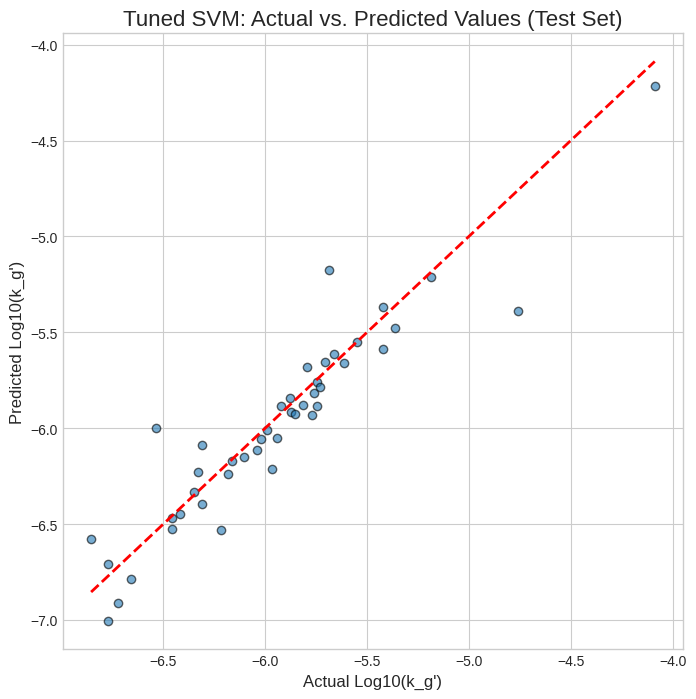

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')

# Create a scatter plot of the actual vs. predicted values for the TEST set
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_test_svm, alpha=0.6, edgecolors='k')

# Add a line for perfect predictions (y=x)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', lw=2)

plt.title('Tuned SVM: Actual vs. Predicted Values (Test Set)', fontsize=16)
plt.xlabel('Actual Log10(k_g\')', fontsize=12)
plt.ylabel('Predicted Log10(k_g\')', fontsize=12)
plt.show()

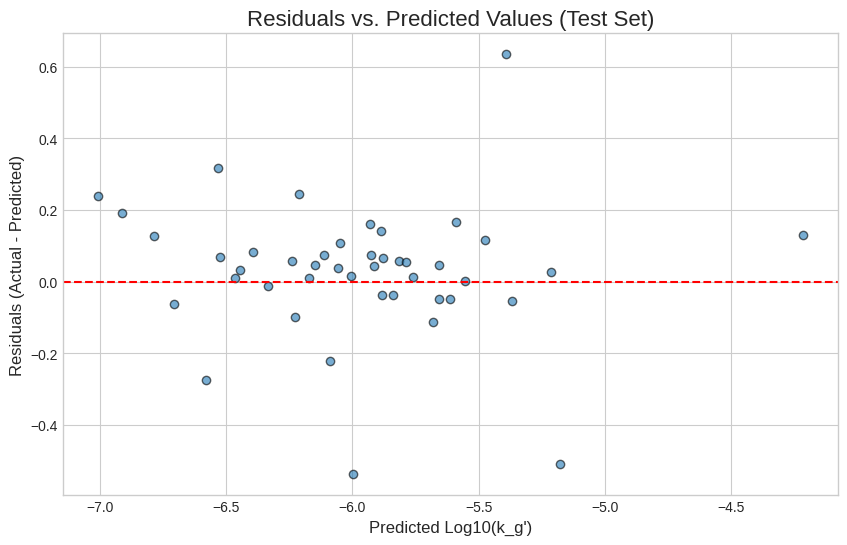

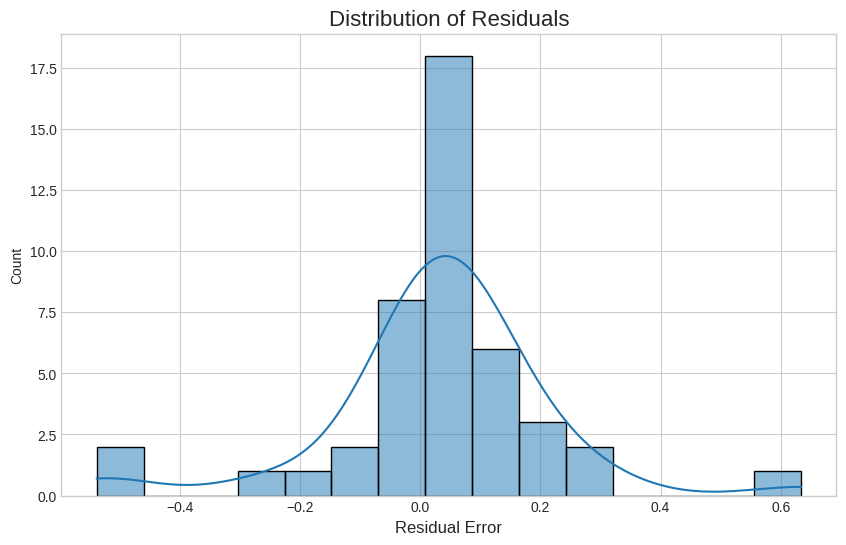

In [24]:
# Calculate the residuals (the errors) for the test set
residuals = y_test - y_pred_test_svm

# Create a scatter plot of the predictions vs. the residuals
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_test_svm, residuals, alpha=0.6, edgecolors='k')

# Add a horizontal line at y=0 (no error)
plt.axhline(y=0, color='red', linestyle='--')

plt.title('Residuals vs. Predicted Values (Test Set)', fontsize=16)
plt.xlabel('Predicted Log10(k_g\')', fontsize=12)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=12)
plt.show()

# Also, plot a histogram of the residuals
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals', fontsize=16)
plt.xlabel('Residual Error', fontsize=12)
plt.show()